In [8]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [9]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"krishnasingh78","key":"f918942630a3df9a2d56dc0653c41765"}'}

In [10]:
!pip install -q kaggle

In [11]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [12]:
!kaggle datasets list -s eurosat

ref                                                              title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
apollo2506/eurosat-dataset                                       EuroSat Dataset                                     2194656567  2020-11-20 06:31:01.283000          24414        118  0.8235294        
ryanholbrook/eurosat                                             EuroSAT                                               86894309  2020-06-08 14:11:20.253000           3442         57  0.6875           
waseemalastal/eurosat-rgb-dataset                                EuroSAT RGB Dataset                                   94317673  2024-11-03 00:34:47.773000            622          4  0.625        

In [13]:
!kaggle datasets download -d apollo2506/eurosat-dataset

Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
100% 2.04G/2.04G [00:18<00:00, 120MB/s]



In [14]:
!unzip -q eurosat-dataset.zip -d /content/eurosat_data

In [15]:
import os

base_path = "/content/eurosat_data"

for root, dirs, files in os.walk(base_path):
    print("ROOT:", root)
    print("DIRS:", dirs[:10])
    print("FILES:", files[:10])
    print("-" * 50)

ROOT: /content/eurosat_data
DIRS: ['EuroSATallBands', 'EuroSAT']
FILES: []
--------------------------------------------------
ROOT: /content/eurosat_data/EuroSATallBands
DIRS: ['Forest', 'Industrial', 'HerbaceousVegetation', 'Residential', 'River', 'Highway', 'Pasture', 'PermanentCrop', 'SeaLake', 'AnnualCrop']
FILES: ['label_map.json', 'train.csv', 'validation.csv', 'test.csv']
--------------------------------------------------
ROOT: /content/eurosat_data/EuroSATallBands/Forest
DIRS: []
FILES: ['Forest_1908.tif', 'Forest_827.tif', 'Forest_2131.tif', 'Forest_594.tif', 'Forest_2648.tif', 'Forest_2413.tif', 'Forest_773.tif', 'Forest_1697.tif', 'Forest_2343.tif', 'Forest_1534.tif']
--------------------------------------------------
ROOT: /content/eurosat_data/EuroSATallBands/Industrial
DIRS: []
FILES: ['Industrial_2194.tif', 'Industrial_41.tif', 'Industrial_179.tif', 'Industrial_1796.tif', 'Industrial_2216.tif', 'Industrial_2378.tif', 'Industrial_1065.tif', 'Industrial_1513.tif', 'Industr

In [16]:
import os

for item in os.listdir("/content/eurosat_data"):
    print(item)

EuroSATallBands
EuroSAT


In [17]:
EUROSAT_PATH = "/content/eurosat_data/EuroSAT"

In [18]:
import os

print("Dataset path exists:", os.path.exists(EUROSAT_PATH))
print("Folders inside dataset path:")
print(os.listdir(EUROSAT_PATH))

Dataset path exists: True
Folders inside dataset path:
['Forest', 'Industrial', 'HerbaceousVegetation', 'label_map.json', 'Residential', 'River', 'Highway', 'Pasture', 'PermanentCrop', 'SeaLake', 'train.csv', 'validation.csv', 'AnnualCrop', 'test.csv']


In [19]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(EUROSAT_PATH, transform=transform)

print("Total images:", len(dataset))
print("Classes:", dataset.classes)
print("Number of classes:", len(dataset.classes))

Total images: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Number of classes: 10


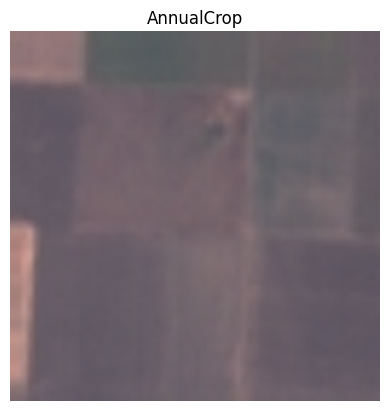

In [20]:
import matplotlib.pyplot as plt

image, label = dataset[0]
plt.imshow(image.permute(1, 2, 0))
plt.title(dataset.classes[label])
plt.axis("off")
plt.show()

In [21]:
!pip install -q scikit-learn seaborn tqdm

In [22]:
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from PIL import Image

import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split

In [23]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
print("Seed set successfully.")

Seed set successfully.


In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
EUROSAT_PATH = "/content/eurosat_data/EuroSAT"
OUTPUT_DIR = "/content/drive/MyDrive/satellite_project_outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/plots", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/metadata", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/checkpoints", exist_ok=True)

print("Dataset path:", EUROSAT_PATH)
print("Output dir:", OUTPUT_DIR)

Dataset path: /content/eurosat_data/EuroSAT
Output dir: /content/drive/MyDrive/satellite_project_outputs


In [26]:
basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(EUROSAT_PATH, transform=basic_transform)

print("Total images:", len(dataset))
print("Classes:", dataset.classes)
print("Number of classes:", len(dataset.classes))

Total images: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Number of classes: 10


In [27]:
class_to_idx = dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

with open(f"{OUTPUT_DIR}/metadata/class_to_idx.json", "w") as f:
    json.dump(class_to_idx, f, indent=4)

with open(f"{OUTPUT_DIR}/metadata/idx_to_class.json", "w") as f:
    json.dump(idx_to_class, f, indent=4)

print("Saved class_to_idx and idx_to_class.")

Saved class_to_idx and idx_to_class.


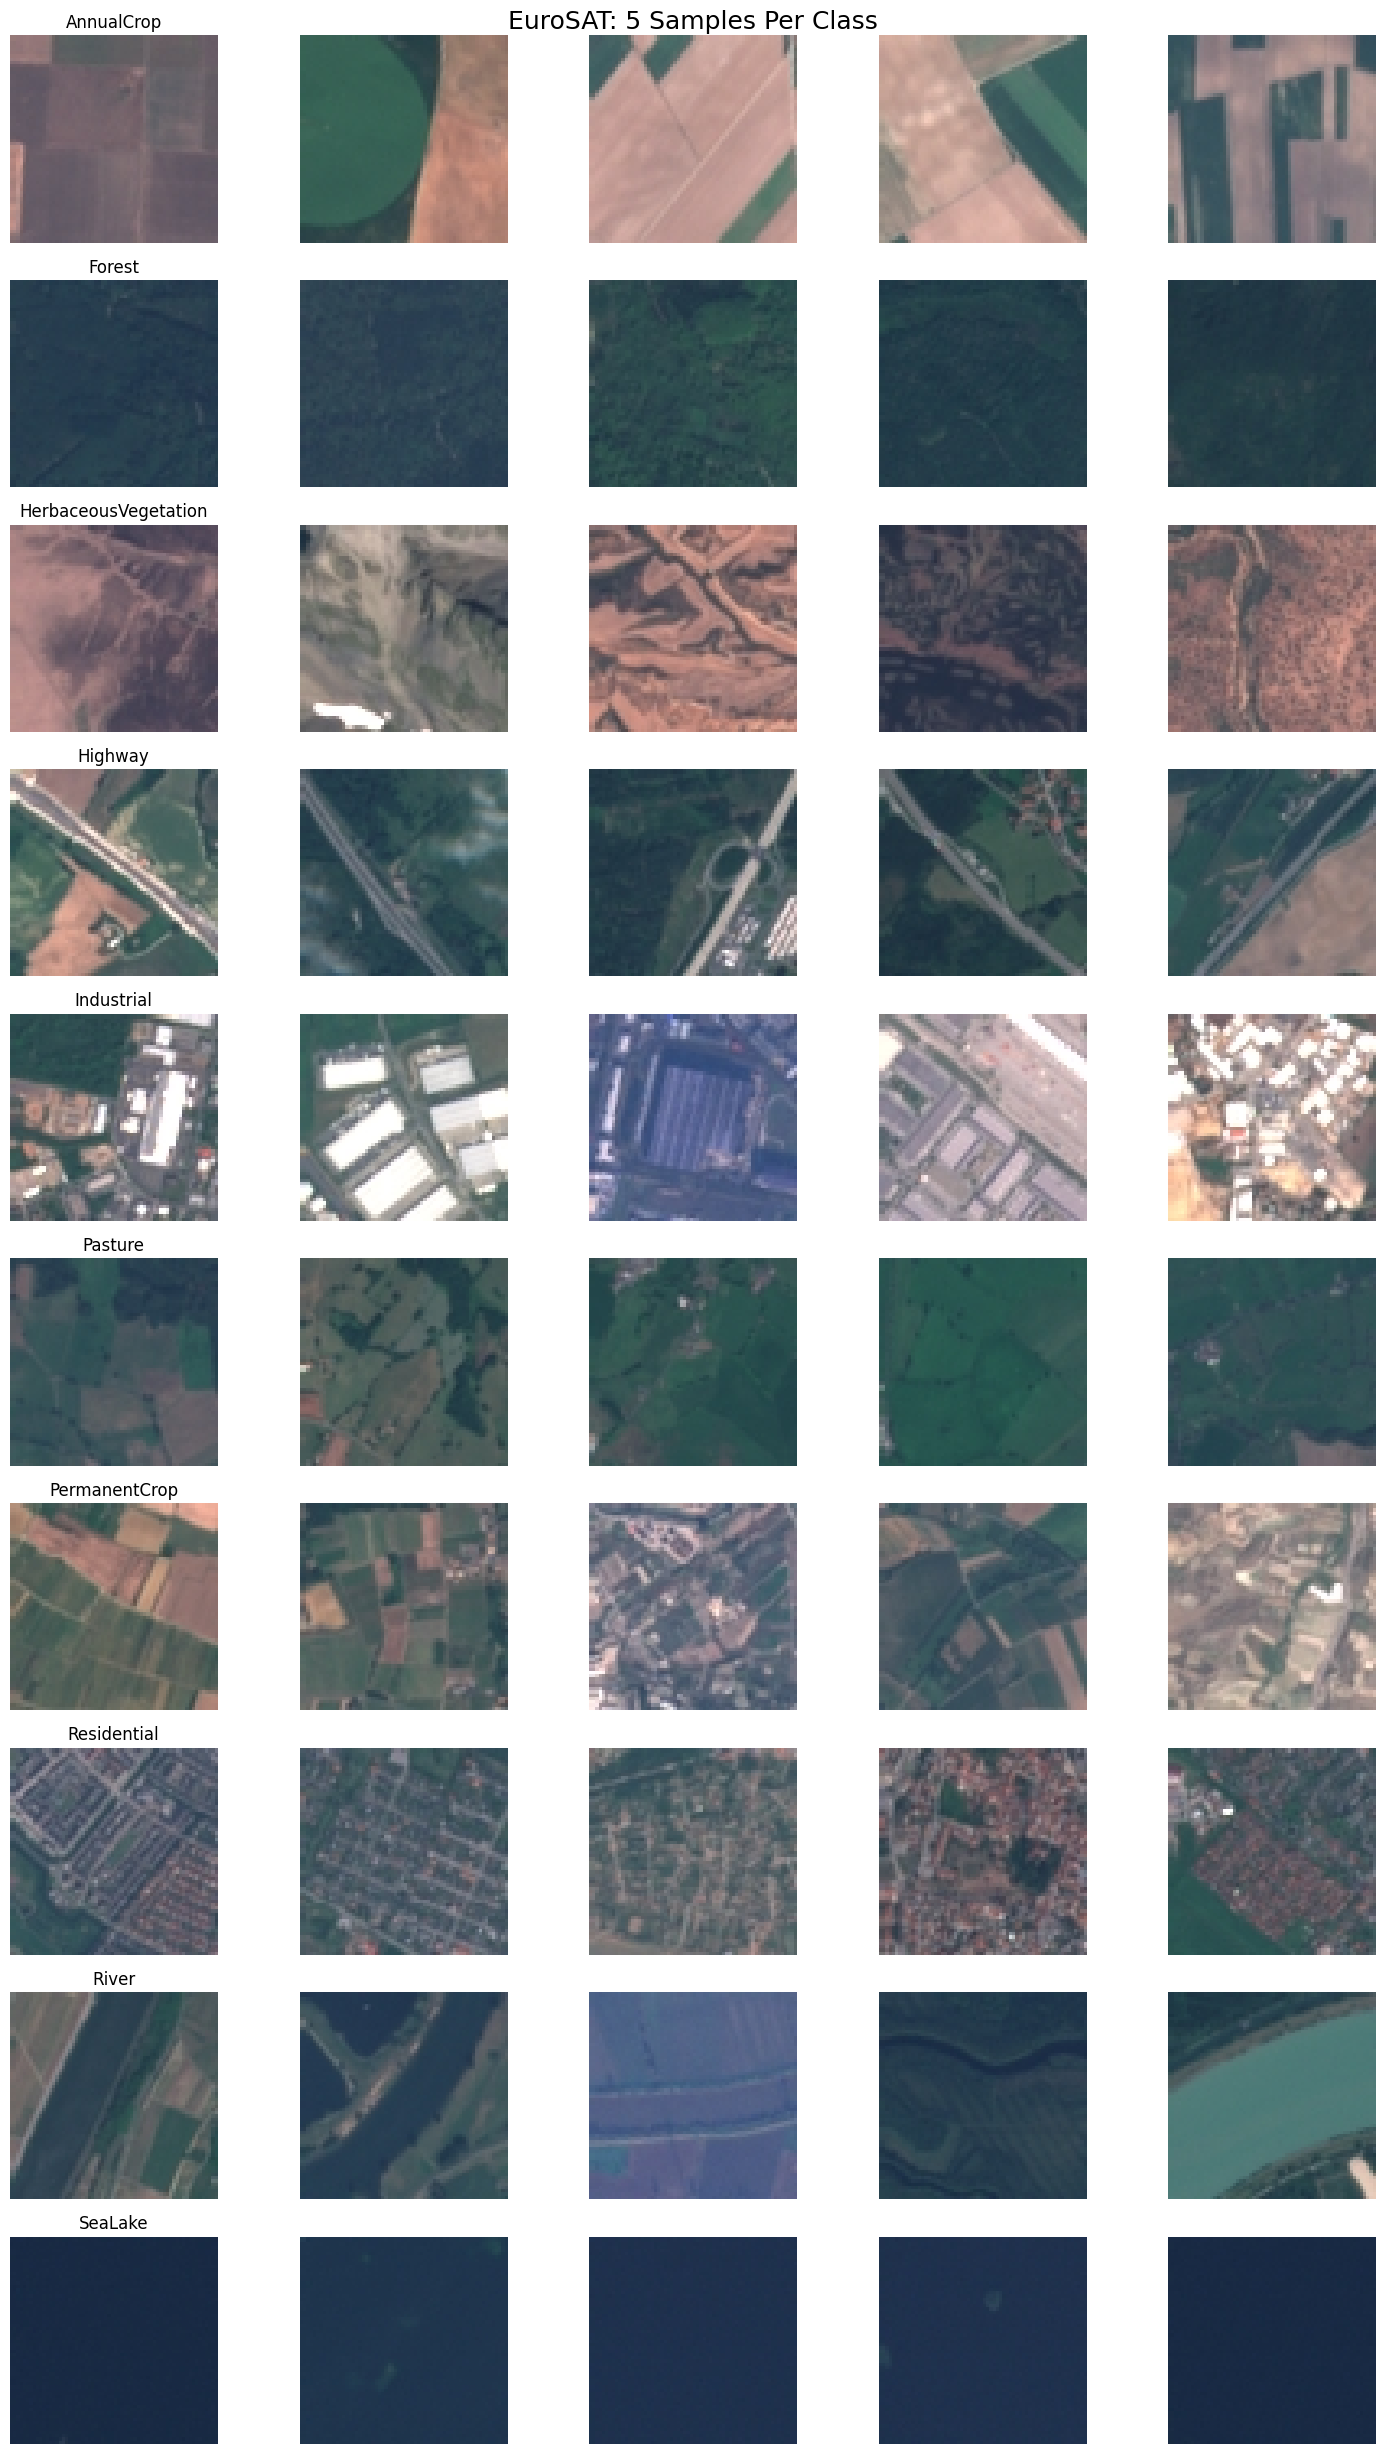

In [28]:
class_names = dataset.classes
samples_per_class = {cls: [] for cls in class_names}

for img_path, label in dataset.samples:
    cls_name = class_names[label]
    if len(samples_per_class[cls_name]) < 5:
        samples_per_class[cls_name].append(img_path)

fig, axes = plt.subplots(len(class_names), 5, figsize=(15, 25))
fig.suptitle("EuroSAT: 5 Samples Per Class", fontsize=18)

for row, cls_name in enumerate(class_names):
    for col in range(5):
        img = Image.open(samples_per_class[cls_name][col]).convert("RGB")
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_title(cls_name)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/5_samples_per_class.png")
plt.show()

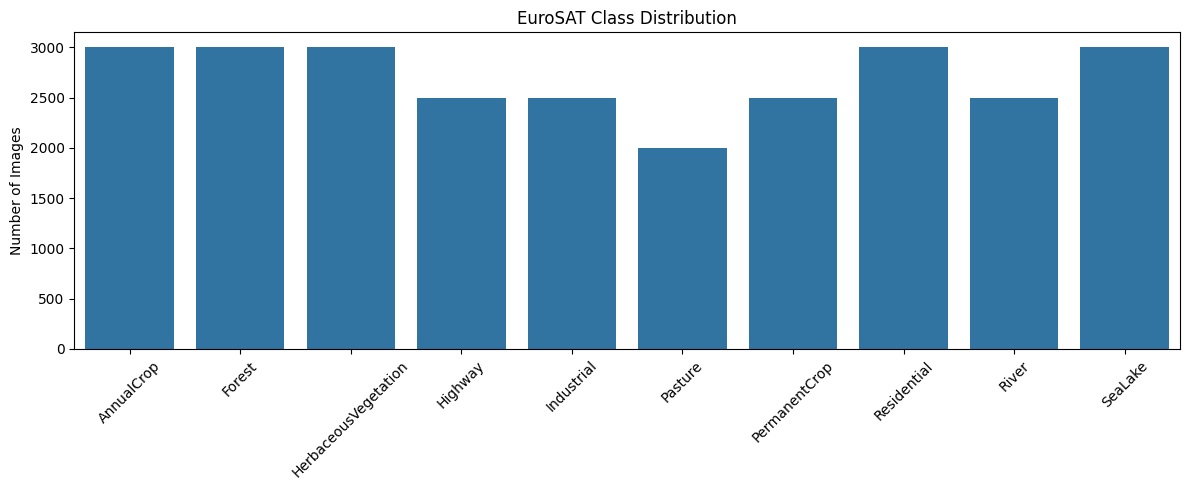

In [29]:
labels = [label for _, label in dataset.samples]
label_counts = Counter(labels)
class_counts = {class_names[k]: v for k, v in label_counts.items()}

plt.figure(figsize=(12, 5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.xticks(rotation=45)
plt.title("EuroSAT Class Distribution")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/class_distribution.png")
plt.show()

In [30]:
all_indices = list(range(len(dataset)))
all_labels = [dataset.samples[i][1] for i in all_indices]

train_idx, temp_idx = train_test_split(
    all_indices,
    test_size=0.30,
    stratify=all_labels,
    random_state=42
)

temp_labels = [dataset.samples[i][1] for i in temp_idx]

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)

print("Train size:", len(train_idx))
print("Validation size:", len(val_idx))
print("Test size:", len(test_idx))

Train size: 18900
Validation size: 4050
Test size: 4050


In [31]:
split_info = {
    "train_idx": train_idx,
    "val_idx": val_idx,
    "test_idx": test_idx
}

with open(f"{OUTPUT_DIR}/metadata/split_indices.json", "w") as f:
    json.dump(split_info, f)

print("Saved split indices.")

Saved split indices.


In [32]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [33]:
train_full = datasets.ImageFolder(EUROSAT_PATH, transform=train_transform)
eval_full = datasets.ImageFolder(EUROSAT_PATH, transform=eval_transform)

train_dataset = Subset(train_full, train_idx)
val_dataset = Subset(eval_full, val_idx)
test_dataset = Subset(eval_full, test_idx)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 18900
Validation samples: 4050
Test samples: 4050


In [34]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("DataLoaders created successfully.")

DataLoaders created successfully.


In [35]:
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

Batch image shape: torch.Size([64, 3, 224, 224])
Batch label shape: torch.Size([64])


In [38]:
print("Notebook 1 data pipeline completed successfully.")

Notebook 1 data pipeline completed successfully.


STEP 3 — Baseline CNN

In [39]:
!pip install -q scikit-learn seaborn tqdm

In [40]:
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [41]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(BaselineCNN, self).__init__()

        # Feature extraction layers
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        # Classification layers
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),  # because 224 -> 112 -> 56 -> 28 after 3 maxpools
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [44]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [45]:
num_classes = len(dataset.classes)

baseline_model = BaselineCNN(num_classes=num_classes).to(device)
print(baseline_model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [46]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)

In [47]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader):
        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Track loss and accuracy
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [48]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    return epoch_loss, epoch_acc, macro_f1, all_labels, all_preds

In [49]:
num_epochs = 8

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
val_f1_scores = []

best_val_f1 = 0.0
best_model_path = f"{OUTPUT_DIR}/checkpoints/baseline_cnn_best.pt"

for epoch in range(num_epochs):
    print(f"\n===== Epoch {epoch+1}/{num_epochs} =====")

    train_loss, train_acc = train_one_epoch(
        baseline_model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc, val_f1, val_labels, val_preds = evaluate_model(
        baseline_model, val_loader, criterion, device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    val_f1_scores.append(val_f1)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val Macro-F1: {val_f1:.4f}")

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(baseline_model.state_dict(), best_model_path)
        print("Best baseline model saved.")


===== Epoch 1/8 =====


100%|██████████| 64/64 [00:07<00:00,  8.22it/s]


Train Loss: 1.3607 | Train Acc: 0.4983
Val Loss:   0.8502 | Val Acc:   0.6928 | Val Macro-F1: 0.6799
Best baseline model saved.

===== Epoch 2/8 =====


100%|██████████| 64/64 [00:09<00:00,  7.10it/s]


Train Loss: 0.9499 | Train Acc: 0.6546
Val Loss:   0.7131 | Val Acc:   0.7368 | Val Macro-F1: 0.7258
Best baseline model saved.

===== Epoch 3/8 =====


...

Train Loss: 0.5700 | Train Acc: 0.8006
Val Loss:   0.5008 | Val Acc:   0.8156 | Val Macro-F1: 0.8054

===== Epoch 7/8 =====


100%|██████████| 64/64 [00:09<00:00,  6.89it/s]


Train Loss: 0.5349 | Train Acc: 0.8155
Val Loss:   0.5615 | Val Acc:   0.8012 | Val Macro-F1: 0.7937

===== Epoch 8/8 =====


100%|██████████| 64/64 [00:09<00:00,  6.97it/s]


Train Loss: 0.5002 | Train Acc: 0.8286
Val Loss:   0.4227 | Val Acc:   0.8501 | Val Macro-F1: 0.8448
Best baseline model saved.


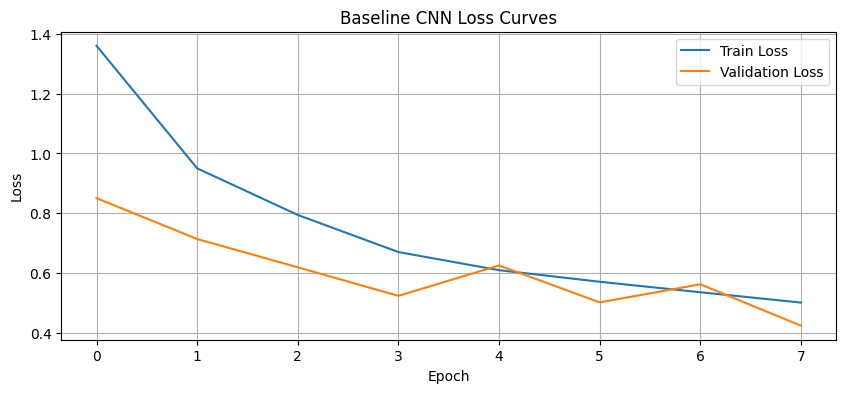

In [50]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Baseline CNN Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig(f"{OUTPUT_DIR}/plots/baseline_loss_curve.png")
plt.show()

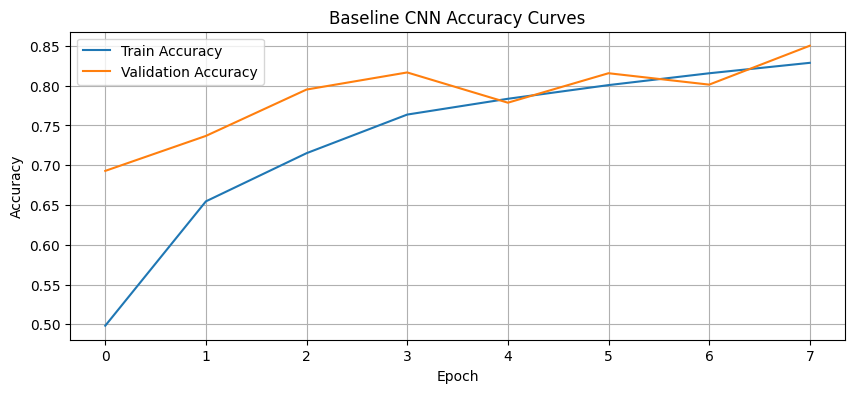

In [51]:
plt.figure(figsize=(10, 4))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.title("Baseline CNN Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(f"{OUTPUT_DIR}/plots/baseline_accuracy_curve.png")
plt.show()

In [52]:
baseline_model.load_state_dict(torch.load(best_model_path))
print("Best baseline model loaded.")

Best baseline model loaded.


In [53]:
val_loss, val_acc, val_f1, val_labels, val_preds = evaluate_model(
    baseline_model, val_loader, criterion, device
)

print("Final Validation Macro-F1:", val_f1)
print("\nClassification Report:\n")
print(classification_report(val_labels, val_preds, target_names=dataset.classes, digits=4))

100%|██████████| 64/64 [00:13<00:00,  4.84it/s]

Final Validation Macro-F1: 0.8447891883595273

Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop     0.9017    0.8356    0.8674       450
              Forest     0.8938    0.9533    0.9226       450
HerbaceousVegetation     0.8424    0.7244    0.7790       450
             Highway     0.7258    0.6987    0.7120       375
          Industrial     0.9370    0.9120    0.9243       375
             Pasture     0.7618    0.8633    0.8094       300
       PermanentCrop     0.6916    0.8613    0.7672       375
         Residential     0.9189    0.9822    0.9495       450
               River     0.8144    0.7253    0.7673       375
             SeaLake     0.9856    0.9156    0.9493       450

            accuracy                         0.8501      4050
           macro avg     0.8473    0.8472    0.8448      4050
        weighted avg     0.8545    0.8501    0.8500      4050



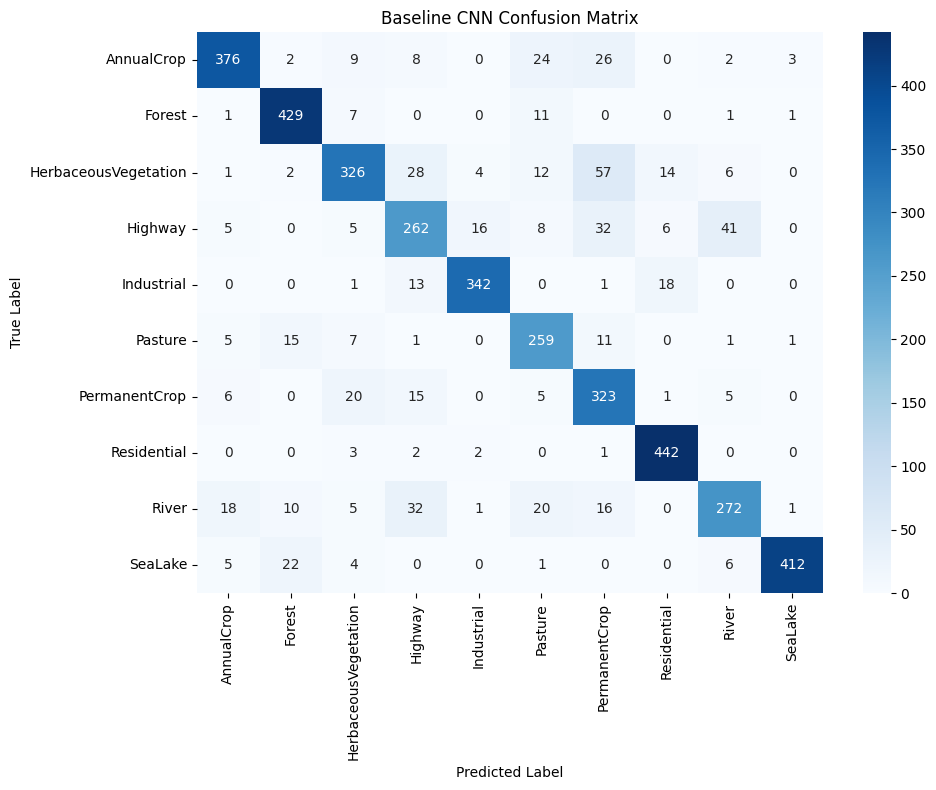

In [54]:
cm = confusion_matrix(val_labels, val_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dataset.classes,
            yticklabels=dataset.classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Baseline CNN Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/baseline_confusion_matrix.png")
plt.show()

In [55]:
baseline_summary = {
    "best_val_macro_f1": float(best_val_f1),
    "final_val_accuracy": float(val_acc),
    "final_val_macro_f1": float(val_f1),
    "model_name": "BaselineCNN"
}

with open(f"{OUTPUT_DIR}/metadata/baseline_summary.json", "w") as f:
    json.dump(baseline_summary, f, indent=4)

print("Baseline summary saved.")

Baseline summary saved.


Step 4 — Transfer Learning with ResNet-18

In [56]:
from torchvision.models import resnet18, ResNet18_Weights
import copy

In [57]:
weights = ResNet18_Weights.DEFAULT
resnet_model = resnet18(weights=weights)

# Replace final classification layer
num_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_features, num_classes)

resnet_model = resnet_model.to(device)
print(resnet_model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 60.9MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

PHASE 1 — Freeze backbone, train only classifier head

In [58]:
for param in resnet_model.parameters():
    param.requires_grad = False

for param in resnet_model.fc.parameters():
    param.requires_grad = True

print("Phase 1 setup complete: only final layer is trainable.")

Phase 1 setup complete: only final layer is trainable.


In [59]:
criterion = nn.CrossEntropyLoss()

# Only train final layer
optimizer = optim.Adam(resnet_model.fc.parameters(), lr=0.001)

In [60]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [61]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * images.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    return epoch_loss, epoch_acc, macro_f1, all_labels, all_preds, all_probs

In [62]:
phase1_epochs = 3

phase1_train_losses = []
phase1_val_losses = []
phase1_val_accs = []
phase1_val_f1s = []

best_phase1_f1 = 0.0
best_phase1_path = f"{OUTPUT_DIR}/checkpoints/resnet18_phase1_best.pt"

for epoch in range(phase1_epochs):
    print(f"\n===== Phase 1 Epoch {epoch+1}/{phase1_epochs} =====")

    train_loss, train_acc = train_one_epoch(
        resnet_model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc, val_f1, val_labels, val_preds, val_probs = evaluate_model(
        resnet_model, val_loader, criterion, device
    )

    phase1_train_losses.append(train_loss)
    phase1_val_losses.append(val_loss)
    phase1_val_accs.append(val_acc)
    phase1_val_f1s.append(val_f1)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val Macro-F1: {val_f1:.4f}")

    if val_f1 > best_phase1_f1:
        best_phase1_f1 = val_f1
        torch.save(resnet_model.state_dict(), best_phase1_path)
        print("Best Phase 1 model saved.")


===== Phase 1 Epoch 1/3 =====


100%|██████████| 64/64 [00:09<00:00,  6.70it/s]


Train Loss: 0.8318 | Train Acc: 0.7647
Val Loss:   0.6205 | Val Acc:   0.8156 | Val Macro-F1: 0.8120
Best Phase 1 model saved.

===== Phase 1 Epoch 2/3 =====


100%|██████████| 64/64 [00:08<00:00,  7.25it/s]


Train Loss: 0.4511 | Train Acc: 0.8588
Val Loss:   0.5090 | Val Acc:   0.8294 | Val Macro-F1: 0.8292
Best Phase 1 model saved.

===== Phase 1 Epoch 3/3 =====


100%|██████████| 64/64 [00:08<00:00,  7.95it/s]


Train Loss: 0.3842 | Train Acc: 0.8776
Val Loss:   0.3917 | Val Acc:   0.8733 | Val Macro-F1: 0.8704
Best Phase 1 model saved.


In [63]:
resnet_model.load_state_dict(torch.load(best_phase1_path))
print("Loaded best Phase 1 model.")

Loaded best Phase 1 model.


PHASE 2 — Unfreeze last 2 conv blocks

In [64]:
for param in resnet_model.parameters():
    param.requires_grad = False

In [65]:
for param in resnet_model.layer3.parameters():
    param.requires_grad = True

for param in resnet_model.layer4.parameters():
    param.requires_grad = True

for param in resnet_model.fc.parameters():
    param.requires_grad = True

print("Phase 2 setup complete: layer3, layer4, and fc are trainable.")

Phase 2 setup complete: layer3, layer4, and fc are trainable.


In [66]:
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, resnet_model.parameters()),
    lr=0.0001
)

In [67]:
phase2_epochs = 5

phase2_train_losses = []
phase2_val_losses = []
phase2_val_accs = []
phase2_val_f1s = []

best_final_f1 = best_phase1_f1
best_final_path = f"{OUTPUT_DIR}/checkpoints/resnet18_best_final.pt"

for epoch in range(phase2_epochs):
    print(f"\n===== Phase 2 Epoch {epoch+1}/{phase2_epochs} =====")

    train_loss, train_acc = train_one_epoch(
        resnet_model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc, val_f1, val_labels, val_preds, val_probs = evaluate_model(
        resnet_model, val_loader, criterion, device
    )

    phase2_train_losses.append(train_loss)
    phase2_val_losses.append(val_loss)
    phase2_val_accs.append(val_acc)
    phase2_val_f1s.append(val_f1)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val Macro-F1: {val_f1:.4f}")

    if val_f1 > best_final_f1:
        best_final_f1 = val_f1
        torch.save(resnet_model.state_dict(), best_final_path)
        print("Best final ResNet-18 model saved.")


===== Phase 2 Epoch 1/5 =====


100%|██████████| 64/64 [00:08<00:00,  7.22it/s]


Train Loss: 0.1992 | Train Acc: 0.9334
Val Loss:   0.1568 | Val Acc:   0.9469 | Val Macro-F1: 0.9462
Best final ResNet-18 model saved.

===== Phase 2 Epoch 2/5 =====


100%|██████████| 64/64 [00:09<00:00,  6.69it/s]


Train Loss: 0.1071 | Train Acc: 0.9616
Val Loss:   0.1046 | Val Acc:   0.9632 | Val Macro-F1: 0.9621
Best final ResNet-18 model saved.

===== Phase 2 Epoch 3/5 =====


...

Train Loss: 0.0880 | Train Acc: 0.9694
Val Loss:   0.0927 | Val Acc:   0.9664 | Val Macro-F1: 0.9658
Best final ResNet-18 model saved.

===== Phase 2 Epoch 4/5 =====


100%|██████████| 64/64 [00:09<00:00,  6.70it/s]


Train Loss: 0.0679 | Train Acc: 0.9767
Val Loss:   0.1006 | Val Acc:   0.9677 | Val Macro-F1: 0.9671
Best final ResNet-18 model saved.

===== Phase 2 Epoch 5/5 =====


100%|██████████| 64/64 [00:09<00:00,  6.68it/s]


Train Loss: 0.0680 | Train Acc: 0.9769
Val Loss:   0.0745 | Val Acc:   0.9775 | Val Macro-F1: 0.9767
Best final ResNet-18 model saved.


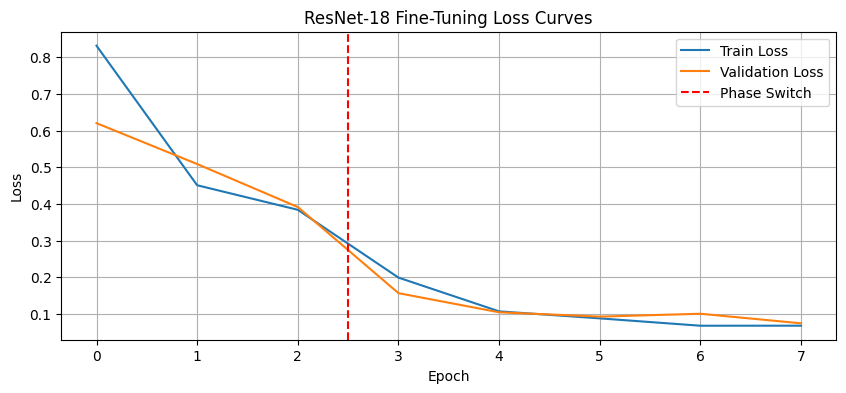

In [68]:
all_train_losses = phase1_train_losses + phase2_train_losses
all_val_losses = phase1_val_losses + phase2_val_losses

plt.figure(figsize=(10, 4))
plt.plot(all_train_losses, label="Train Loss")
plt.plot(all_val_losses, label="Validation Loss")
plt.axvline(x=2.5, color='red', linestyle='--', label='Phase Switch')
plt.title("ResNet-18 Fine-Tuning Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig(f"{OUTPUT_DIR}/plots/resnet18_loss_curve.png")
plt.show()

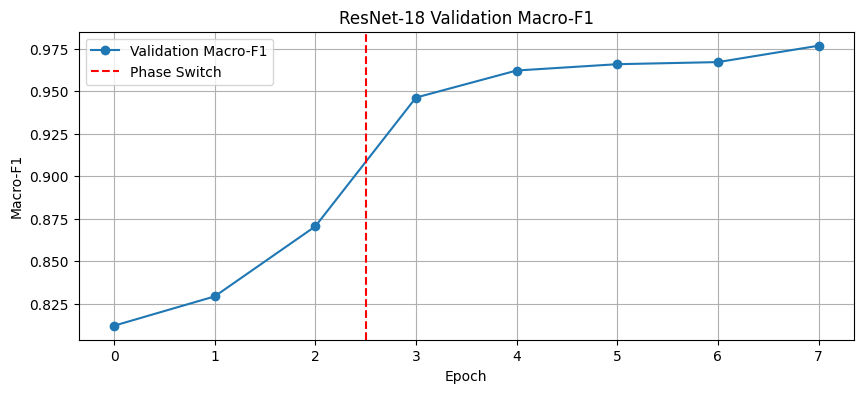

In [69]:
all_val_f1s = phase1_val_f1s + phase2_val_f1s

plt.figure(figsize=(10, 4))
plt.plot(all_val_f1s, marker='o', label="Validation Macro-F1")
plt.axvline(x=2.5, color='red', linestyle='--', label='Phase Switch')
plt.title("ResNet-18 Validation Macro-F1")
plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.legend()
plt.grid(True)
plt.savefig(f"{OUTPUT_DIR}/plots/resnet18_f1_curve.png")
plt.show()

In [70]:
resnet_model.load_state_dict(torch.load(best_final_path))
print("Best final ResNet-18 model loaded.")

Best final ResNet-18 model loaded.


In [71]:
val_loss, val_acc, val_f1, val_labels, val_preds, val_probs = evaluate_model(
    resnet_model, val_loader, criterion, device
)

print("Final Validation Accuracy:", val_acc)
print("Final Validation Macro-F1:", val_f1)
print("\nClassification Report:\n")
print(classification_report(val_labels, val_preds, target_names=dataset.classes, digits=4))

100%|██████████| 64/64 [00:09<00:00,  6.69it/s]

Final Validation Accuracy: 0.9775308641975309
Final Validation Macro-F1: 0.9767109955781865

Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop     0.9840    0.9556    0.9696       450
              Forest     0.9978    0.9978    0.9978       450
HerbaceousVegetation     0.9565    0.9778    0.9670       450
             Highway     0.9440    0.9893    0.9661       375
          Industrial     0.9867    0.9867    0.9867       375
             Pasture     0.9829    0.9600    0.9713       300
       PermanentCrop     0.9398    0.9573    0.9485       375
         Residential     1.0000    0.9889    0.9944       450
               River     0.9783    0.9600    0.9690       375
             SeaLake     1.0000    0.9933    0.9967       450

            accuracy                         0.9775      4050
           macro avg     0.9770    0.9767    0.9767      4050
        weighted avg     0.9779    0.9775    0.9776      4050



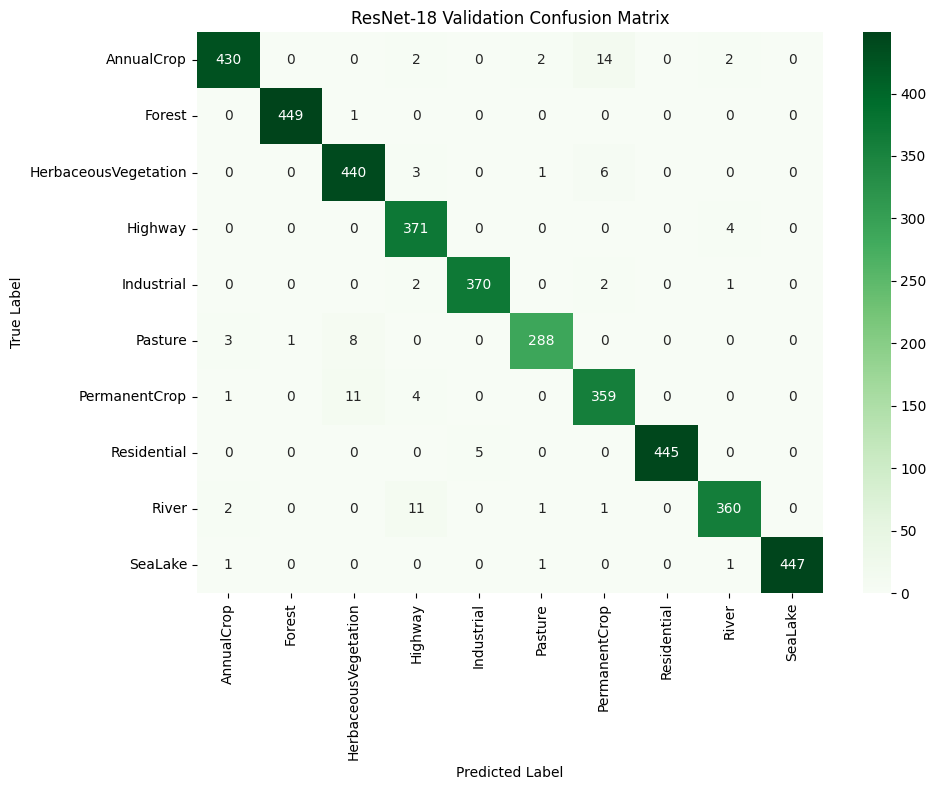

In [72]:
cm = confusion_matrix(val_labels, val_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=dataset.classes,
            yticklabels=dataset.classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ResNet-18 Validation Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/resnet18_confusion_matrix.png")
plt.show()

In [73]:
test_loss, test_acc, test_f1, test_labels, test_preds, test_probs = evaluate_model(
    resnet_model, test_loader, criterion, device
)

print("Test Accuracy:", test_acc)
print("Test Macro-F1:", test_f1)
print("\nTest Classification Report:\n")
print(classification_report(test_labels, test_preds, target_names=dataset.classes, digits=4))

100%|██████████| 64/64 [00:09<00:00,  6.66it/s]

Test Accuracy: 0.9790123456790123
Test Macro-F1: 0.9782182042282273

Test Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop     0.9795    0.9578    0.9685       450
              Forest     0.9978    0.9956    0.9967       450
HerbaceousVegetation     0.9630    0.9844    0.9736       450
             Highway     0.9397    0.9973    0.9677       375
          Industrial     0.9893    0.9840    0.9866       375
             Pasture     0.9796    0.9600    0.9697       300
       PermanentCrop     0.9497    0.9573    0.9535       375
         Residential     0.9955    0.9889    0.9922       450
               River     0.9918    0.9627    0.9770       375
             SeaLake     1.0000    0.9933    0.9967       450

            accuracy                         0.9790      4050
           macro avg     0.9786    0.9781    0.9782      4050
        weighted avg     0.9794    0.9790    0.9791      4050



In [74]:
resnet_summary = {
    "phase1_best_val_f1": float(best_phase1_f1),
    "best_final_val_f1": float(best_final_f1),
    "final_val_accuracy": float(val_acc),
    "final_val_macro_f1": float(val_f1),
    "test_accuracy": float(test_acc),
    "test_macro_f1": float(test_f1),
    "model_name": "ResNet18_TwoPhase_FineTuning"
}

with open(f"{OUTPUT_DIR}/metadata/resnet18_summary.json", "w") as f:
    json.dump(resnet_summary, f, indent=4)

print("ResNet-18 summary saved.")

ResNet-18 summary saved.


In [75]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Phase": ["Frozen Backbone (Phase 1)", "Unfrozen Last 2 Blocks (Final)"],
    "Best Val Macro-F1": [best_phase1_f1, best_final_f1]
})

print(comparison_df)

comparison_df.to_csv(f"{OUTPUT_DIR}/metadata/frozen_vs_unfrozen_comparison.csv", index=False)

                            Phase  Best Val Macro-F1
0       Frozen Backbone (Phase 1)           0.870421
1  Unfrozen Last 2 Blocks (Final)           0.976711


UC Merced Download in Colab

In [78]:
import os

print("MyDrive contents:")
print(os.listdir("/content/drive/MyDrive"))

MyDrive contents:
['Colab Notebooks', 'IMG20240321184348.jpg', 'IMG_20240325_163947_841.jpg', 'in.gov.abc-ABCID-457551442113.jpeg', 'IMG20240730111344.jpg', '18-1.png', 'Krishna Singh.pdf', 'PCE23CS082_KRISHNA SINGH.pdf', 'krishnaadar.pdf', 'Krishna Singh_NCET( National Competence Evaluation Test) 2026 - 2027_Report.pdf', 'Krishna_Singh_Adhaar.pdf', 'Krishna_Singh_PCE23CS082 (4).pdf', 'Krishna_Singh_Resume.pdf', 'Krishna_Singh_PCE23CS082 (2).pdf', 'Krishna_Singh_PCE23CS082 (1).pdf', 'aaa.jpeg', 'Krishna_Singh_PCE23CS082 (3).pdf', 'Krishna_Pan_card.pdf', 'Krishna_Singh_PCE23CS082_pdf.pdf', 'Krishna_Singh_PCE23CS082_pdf (3).pdf', 'week1_krishna_singh_pce.ipynb', 'week2_krishna_singh_pce (1).ipynb', '1781074184546.pdf', 'week4_Assignment_CIFAR10_ANN_CNN_Learning_Project.ipynb', 'Untitled document.gdoc', 'KrishnaAI Labs - India Runs Submission.gslides', 'autoencoder_denoising.ipynb', 'CEI_DS_week5_Assignment_Krishna_Singh_PCE (1).ipynb', 'Krishna_Singh_PCE23CS082.pdf', 'CEI_DS_Week_7_Assig

In [79]:
for root, dirs, files in os.walk("/content/drive/MyDrive/datasets/UCMerced_LandUse"):
    print("ROOT:", root)
    print("DIRS:", dirs[:10])
    print("FILES:", files[:5])
    print("-"*50)

In [81]:
UCMERCED_PATH = "/content/drive/MyDrive/UCMerced_LandUse/Images"

print("Path exists:", os.path.exists(UCMERCED_PATH))
if os.path.exists(UCMERCED_PATH):
    print(os.listdir(UCMERCED_PATH)[:10])

Path exists: True
['agricultural', 'forest', 'denseresidential', 'freeway', 'runway', 'overpass', 'storagetanks', 'parkinglot', 'chaparral', 'mediumresidential']


UC MERCED EVALUATION CODE

In [82]:
uc_to_eurosat_mapping = {
    "agricultural": "AnnualCrop",
    "forest": "Forest",
    "freeway": "Highway",
    "intersection": "Highway",
    "overpass": "Highway",
    "buildings": "Industrial",
    "parkinglot": "Industrial",
    "dense_residential": "Residential",
    "medium_residential": "Residential",
    "sparse_residential": "Residential",
    "river": "River",
    "harbor": "SeaLake"
}

In [83]:
eurosat_class_to_idx = dataset.class_to_idx
idx_to_eurosat = {v: k for k, v in eurosat_class_to_idx.items()}

print(eurosat_class_to_idx)

{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


In [84]:
from torch.utils.data import Dataset
from PIL import Image

class UCMercedMappedDataset(Dataset):
    def __init__(self, root_dir, mapping, eurosat_class_to_idx, transform=None):
        self.samples = []
        self.transform = transform

        for uc_class in os.listdir(root_dir):
            class_path = os.path.join(root_dir, uc_class)

            if not os.path.isdir(class_path):
                continue

            if uc_class not in mapping:
                continue

            eurosat_class = mapping[uc_class]
            label_idx = eurosat_class_to_idx[eurosat_class]

            for file_name in os.listdir(class_path):
                if file_name.lower().endswith((".jpg", ".jpeg", ".png", ".tif")):
                    img_path = os.path.join(class_path, file_name)
                    self.samples.append((img_path, label_idx, uc_class, eurosat_class))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label_idx, uc_class, eurosat_class = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label_idx, uc_class, eurosat_class

In [85]:
uc_dataset = UCMercedMappedDataset(
    root_dir=UCMERCED_PATH,
    mapping=uc_to_eurosat_mapping,
    eurosat_class_to_idx=eurosat_class_to_idx,
    transform=eval_transform
)

print("Total mapped UC Merced samples:", len(uc_dataset))

Total mapped UC Merced samples: 900


In [86]:
uc_loader = DataLoader(
    uc_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

print("UC Merced DataLoader ready.")

UC Merced DataLoader ready.


In [87]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import numpy as np
from tqdm import tqdm

resnet_model.eval()

all_labels = []
all_preds = []
all_uc_classes = []
all_mapped_classes = []

with torch.no_grad():
    for images, labels, uc_classes, mapped_classes in tqdm(uc_loader):
        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet_model(images)
        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_uc_classes.extend(list(uc_classes))
        all_mapped_classes.extend(list(mapped_classes))

100%|██████████| 15/15 [02:10<00:00,  8.72s/it]


In [88]:
uc_accuracy = accuracy_score(all_labels, all_preds)
uc_macro_f1 = f1_score(all_labels, all_preds, average='macro')

print("UC Merced Accuracy:", uc_accuracy)
print("UC Merced Macro-F1:", uc_macro_f1)

UC Merced Accuracy: 0.5355555555555556
UC Merced Macro-F1: 0.31859439785160826


In [89]:
used_label_indices = sorted(list(set(all_labels)))
used_class_names = [idx_to_eurosat[idx] for idx in used_label_indices]

print("Used mapped classes:", used_class_names)

Used mapped classes: ['AnnualCrop', 'Forest', 'Highway', 'Industrial', 'River', 'SeaLake']


In [90]:
print(classification_report(
    all_labels,
    all_preds,
    labels=used_label_indices,
    target_names=used_class_names,
    digits=4
))

              precision    recall  f1-score   support

  AnnualCrop     0.5217    0.4800    0.5000       100
      Forest     0.7778    0.4900    0.6012       100
     Highway     0.9437    0.4467    0.6063       300
  Industrial     0.5833    0.8400    0.6885       200
       River     0.4662    0.6200    0.5322       100
     SeaLake     0.3333    0.2100    0.2577       100

   micro avg     0.6172    0.5356    0.5735       900
   macro avg     0.6043    0.5144    0.5310       900
weighted avg     0.6774    0.5356    0.5652       900



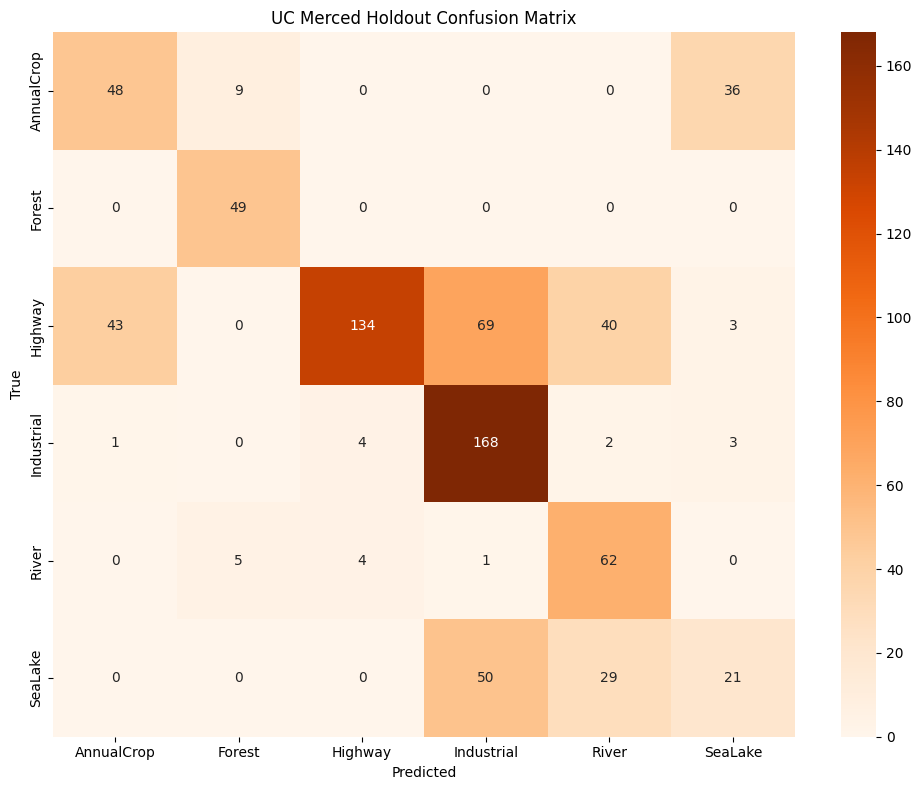

In [91]:
cm_uc = confusion_matrix(all_labels, all_preds, labels=used_label_indices)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_uc,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=used_class_names,
    yticklabels=used_class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("UC Merced Holdout Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/ucmerced_confusion_matrix.png")
plt.show()

In [92]:
uc_summary = {
    "uc_holdout_accuracy": float(uc_accuracy),
    "uc_holdout_macro_f1": float(uc_macro_f1),
    "num_samples_used": len(uc_dataset),
    "mapped_classes": used_class_names
}

with open(f"{OUTPUT_DIR}/metadata/ucmerced_summary.json", "w") as f:
    json.dump(uc_summary, f, indent=4)

print("UC Merced summary saved.")

UC Merced summary saved.


STEP 6 — TEMPORAL CHANGE DETECTION

In [93]:
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn
import torch

weights = ResNet18_Weights.DEFAULT
embedding_model = resnet18(weights=weights)

num_features = embedding_model.fc.in_features
embedding_model.fc = nn.Linear(num_features, num_classes)

embedding_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/checkpoints/resnet18_best_final.pt"))
embedding_model = embedding_model.to(device)
embedding_model.eval()

print("Best trained ResNet-18 model loaded.")

Best trained ResNet-18 model loaded.


In [94]:
feature_extractor = nn.Sequential(*list(embedding_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

print("Feature extractor ready.")

Feature extractor ready.


In [95]:
def extract_embeddings(model, dataloader, device):
    model.eval()

    embeddings = []
    labels = []
    image_paths = []

    subset_indices = dataloader.dataset.indices
    base_dataset = dataloader.dataset.dataset

    sample_counter = 0

    with torch.no_grad():
        for images, batch_labels in tqdm(dataloader):
            images = images.to(device)

            outputs = model(images)                 # [B, 512, 1, 1]
            outputs = outputs.view(outputs.size(0), -1)   # [B, 512]

            embeddings.append(outputs.cpu())
            labels.extend(batch_labels.numpy())

            batch_size = images.size(0)
            for i in range(batch_size):
                real_index = subset_indices[sample_counter]
                img_path, _ = base_dataset.samples[real_index]
                image_paths.append(img_path)
                sample_counter += 1

    embeddings = torch.cat(embeddings, dim=0)
    return embeddings, labels, image_paths

In [96]:
test_embeddings, test_labels, test_image_paths = extract_embeddings(
    feature_extractor, test_loader, device
)

print("Embeddings shape:", test_embeddings.shape)
print("Number of labels:", len(test_labels))
print("Number of image paths:", len(test_image_paths))

100%|██████████| 64/64 [00:12<00:00,  4.99it/s]

Embeddings shape: torch.Size([4050, 512])
Number of labels: 4050
Number of image paths: 4050


In [97]:
idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}

In [98]:
from collections import defaultdict
import random

class_to_indices = defaultdict(list)

for idx, label in enumerate(test_labels):
    class_to_indices[label].append(idx)

print("Grouped test samples by class.")

Grouped test samples by class.


In [99]:
unchanged_pairs = []

for label, indices in class_to_indices.items():
    if len(indices) < 2:
        continue

    # Create up to 50 unchanged pairs per class
    num_pairs = min(50, len(indices) // 2)

    for _ in range(num_pairs):
        i1, i2 = random.sample(indices, 2)
        unchanged_pairs.append((i1, i2, 0))   # 0 = unchanged

print("Number of unchanged pairs:", len(unchanged_pairs))

Number of unchanged pairs: 500


In [100]:
all_class_labels = list(class_to_indices.keys())
changed_pairs = []

for _ in range(len(unchanged_pairs)):
    label1, label2 = random.sample(all_class_labels, 2)
    i1 = random.choice(class_to_indices[label1])
    i2 = random.choice(class_to_indices[label2])
    changed_pairs.append((i1, i2, 1))   # 1 = changed

print("Number of changed pairs:", len(changed_pairs))

Number of changed pairs: 500


In [101]:
all_pairs = unchanged_pairs + changed_pairs
random.shuffle(all_pairs)

print("Total number of pairs:", len(all_pairs))

Total number of pairs: 1000


In [102]:
import torch.nn.functional as F

def cosine_similarity_pair(emb1, emb2):
    return F.cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0)).item()

In [103]:
similarity_scores = []
true_change_labels = []

for i1, i2, change_label in tqdm(all_pairs):
    emb1 = test_embeddings[i1]
    emb2 = test_embeddings[i2]

    sim = cosine_similarity_pair(emb1, emb2)

    similarity_scores.append(sim)
    true_change_labels.append(change_label)

print("Computed similarity scores for all pairs.")

100%|██████████| 1000/1000 [00:00<00:00, 6106.03it/s]

Computed similarity scores for all pairs.


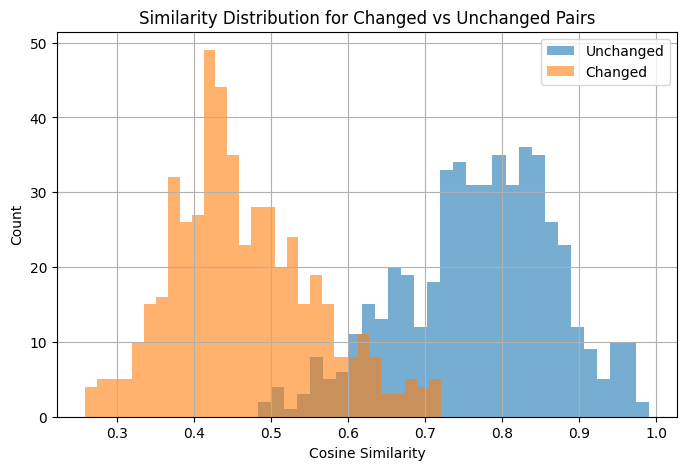

In [104]:
plt.figure(figsize=(8, 5))

unchanged_sims = [s for s, y in zip(similarity_scores, true_change_labels) if y == 0]
changed_sims = [s for s, y in zip(similarity_scores, true_change_labels) if y == 1]

plt.hist(unchanged_sims, bins=30, alpha=0.6, label="Unchanged")
plt.hist(changed_sims, bins=30, alpha=0.6, label="Changed")

plt.xlabel("Cosine Similarity")
plt.ylabel("Count")
plt.title("Similarity Distribution for Changed vs Unchanged Pairs")
plt.legend()
plt.grid(True)
plt.savefig(f"{OUTPUT_DIR}/plots/change_similarity_distribution.png")
plt.show()

In [106]:
change_scores = [1 - s for s in similarity_scores]

In [107]:
from sklearn.metrics import roc_curve, auc

change_scores = [1 - s for s in similarity_scores]

fpr, tpr, thresholds = roc_curve(true_change_labels, change_scores)
roc_auc = auc(fpr, tpr)

print("ROC AUC:", roc_auc)

ROC AUC: 0.982312


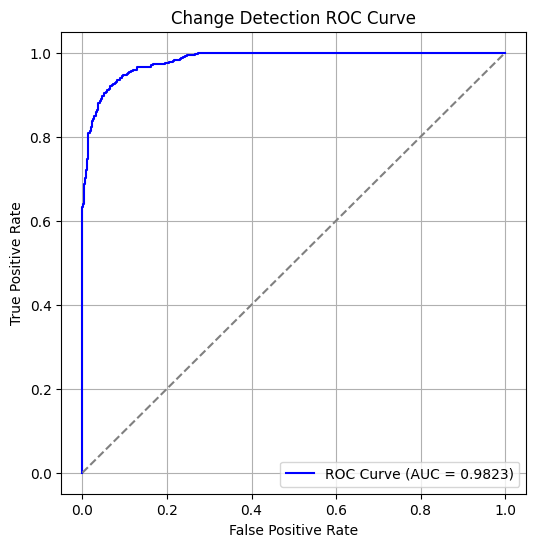

In [108]:
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})", color="blue")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Change Detection ROC Curve")
plt.legend()
plt.grid(True)
plt.savefig(f"{OUTPUT_DIR}/plots/change_detection_roc_curve.png")
plt.show()

In [109]:
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)

best_threshold_change_score = thresholds[best_idx]
best_similarity_threshold = 1 - best_threshold_change_score

print("Best change-score threshold:", best_threshold_change_score)
print("Selected cosine similarity threshold:", best_similarity_threshold)

Best change-score threshold: 0.3920389413833618
Selected cosine similarity threshold: 0.6079610586166382


In [110]:
predicted_change_labels = [
    1 if sim < best_similarity_threshold else 0
    for sim in similarity_scores
]

In [111]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

change_accuracy = accuracy_score(true_change_labels, predicted_change_labels)
change_macro_f1 = f1_score(true_change_labels, predicted_change_labels, average='macro')

print("Change Detection Accuracy:", change_accuracy)
print("Change Detection Macro-F1:", change_macro_f1)

print("\nClassification Report:\n")
print(classification_report(
    true_change_labels,
    predicted_change_labels,
    target_names=["Unchanged", "Changed"],
    digits=4
))

Change Detection Accuracy: 0.926
Change Detection Macro-F1: 0.9259952636968767

Classification Report:

              precision    recall  f1-score   support

   Unchanged     0.9193    0.9340    0.9266       500
     Changed     0.9329    0.9180    0.9254       500

    accuracy                         0.9260      1000
   macro avg     0.9261    0.9260    0.9260      1000
weighted avg     0.9261    0.9260    0.9260      1000



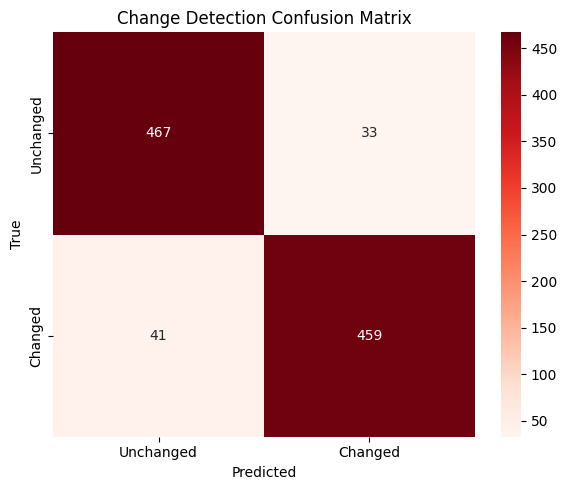

In [112]:
cm_change = confusion_matrix(true_change_labels, predicted_change_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_change,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=["Unchanged", "Changed"],
    yticklabels=["Unchanged", "Changed"]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Change Detection Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/change_detection_confusion_matrix.png")
plt.show()

In [113]:
from PIL import Image
import cv2

def load_image_for_display(path, size=(224, 224)):
    img = Image.open(path).convert("RGB")
    img = img.resize(size)
    return np.array(img)

In [114]:
from PIL import Image
import cv2

def load_image_for_display(path, size=(224, 224)):
    img = Image.open(path).convert("RGB")
    img = img.resize(size)
    return np.array(img)

In [115]:
def create_change_heatmap(img1, img2):
    diff = np.abs(img1.astype(np.float32) - img2.astype(np.float32))
    heatmap = diff.mean(axis=2)

    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    return heatmap

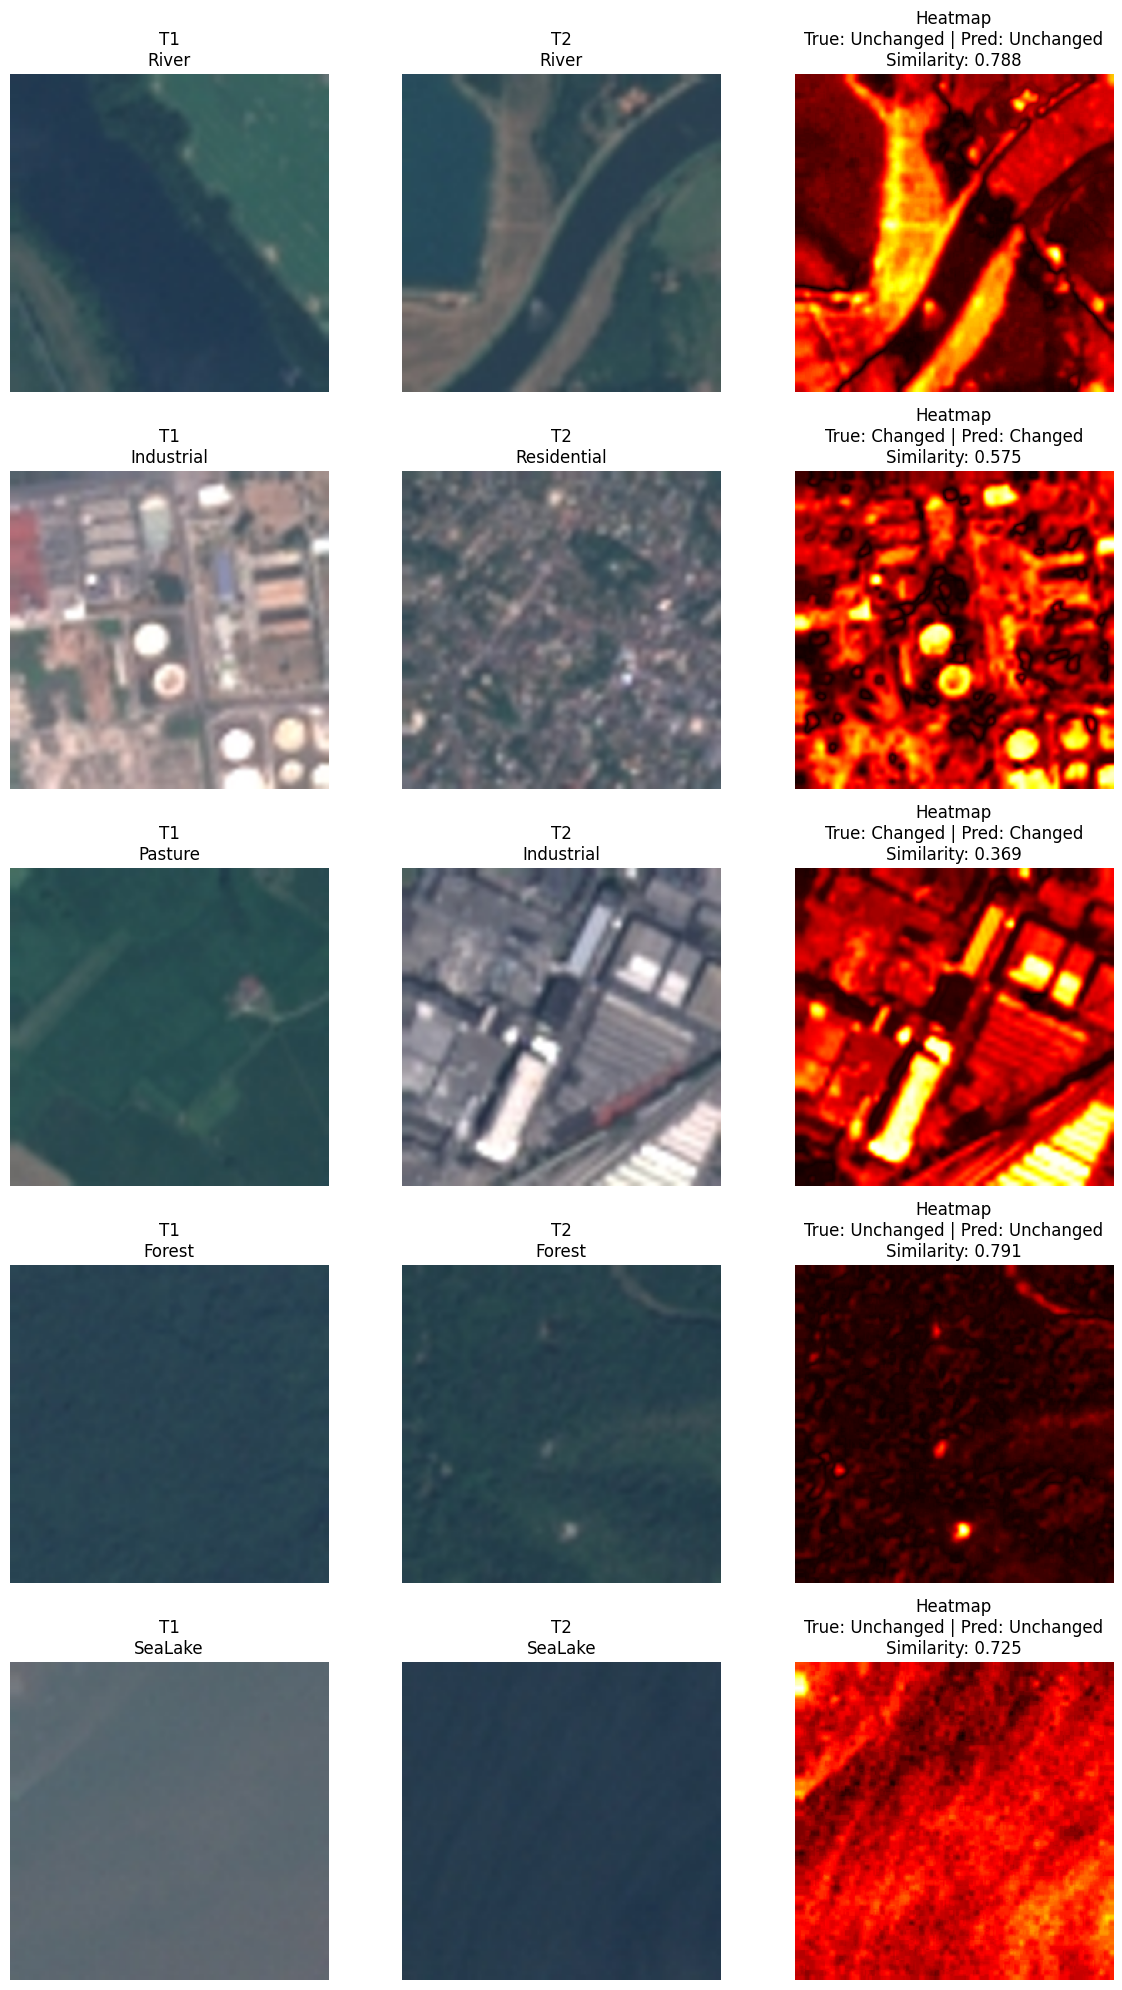

In [116]:
sample_pairs = all_pairs[:5]

fig, axes = plt.subplots(len(sample_pairs), 3, figsize=(12, 4 * len(sample_pairs)))

for row, (i1, i2, change_label) in enumerate(sample_pairs):
    path1 = test_image_paths[i1]
    path2 = test_image_paths[i2]

    img1 = load_image_for_display(path1)
    img2 = load_image_for_display(path2)

    heatmap = create_change_heatmap(img1, img2)

    sim = cosine_similarity_pair(test_embeddings[i1], test_embeddings[i2])
    pred_change = 1 if sim < best_similarity_threshold else 0

    axes[row, 0].imshow(img1)
    axes[row, 0].set_title(f"T1\n{idx_to_class[test_labels[i1]]}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(img2)
    axes[row, 1].set_title(f"T2\n{idx_to_class[test_labels[i2]]}")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(heatmap, cmap="hot")
    axes[row, 2].set_title(
        f"Heatmap\nTrue: {'Changed' if change_label==1 else 'Unchanged'} | "
        f"Pred: {'Changed' if pred_change==1 else 'Unchanged'}\n"
        f"Similarity: {sim:.3f}"
    )
    axes[row, 2].axis("off")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/change_heatmaps_5_samples.png")
plt.show()

In [117]:
change_summary = {
    "roc_auc": float(roc_auc),
    "selected_similarity_threshold": float(best_similarity_threshold),
    "change_detection_accuracy": float(change_accuracy),
    "change_detection_macro_f1": float(change_macro_f1),
    "num_pairs_evaluated": len(all_pairs)
}

with open(f"{OUTPUT_DIR}/metadata/change_detection_summary.json", "w") as f:
    json.dump(change_summary, f, indent=4)

print("Change detection summary saved.")

Change detection summary saved.
